In [33]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


# testing functions

In [34]:
def equally_spaced_positions(N,d):
    if N % 2 == 1:
        positions = np.arange(-(N//2), N//2 + 1) * d
    else:
        # for even N, center between two ions
        positions = (np.arange(-N/2 + 0.5, N/2 + 0.5)) * d
    positions_list = positions.tolist()
    return positions_list

In [35]:
def ion_force_quartic(positions, N, k4, omega_rf_axial):
    """
    Calculate force on each ion.
    
    Inputs:
    -----------
    positions : array-like
        Position of each ion (length N)
    N : int
        Number of ions
    k4 : float
        Quartic interaction coefficient
    omega_rf_axial : float
        Axial trapping frequency from rf potential (2*pi*Hz)
    
    Returns:
    --------
    force_list : list
        Force on each ion (length N)
    """
    x = np.array(positions)
    N = len(x)
    A = 0.5 * m * omega_rf_axial**2
    B = (e**2) / (4 * pi * eps0)
    C = k4

    return [2*A*(x[m]) + 4*C * (x[m]**3) 
            - sum([B * (x[m] - x[n]) / (abs(x[m] - x[n])**3) for n in range(m) if x[m] != x[n]])  # Avoid division by zero
            + sum([B * (x[m] - x[n]) / (abs(x[m] - x[n])**3) for n in range(m+1, N) if x[m] != x[n]])  # Avoid division by zero
           
            for m in range(N)]


N = 15
k4 = 0.00177
omega_rf_axial = 150e3*2*pi
estimated_extreme = 0.481*N**0.765
x0 = np.linspace(-estimated_extreme, estimated_extreme, N)

ueq_test = fsolve(ion_force_quartic, x0, args=(N, k4, omega_rf_axial))
diff_list = []
for x, y in zip(ueq_test[0::], ueq_test[1::]):
    diff_list.append(y-x)
diff_list

/Users/ritika/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


[5.231334134260145e-06,
 4.323839194694244e-06,
 4.72025407683626e-06,
 3.44286201413891e-06,
 7.1912297104941415e-06,
 4.469411295911118e-06,
 -7.2870498116343415e-06,
 1.781096366938332e-05,
 3.011792890101129e-06,
 -7.898670131382756e-06,
 9.874248939254035e-06,
 2.2413323608826758e-06,
 3.211509994864699e-06,
 1.7354252790722454e-06]

# trying functions

### I am assuming the potential is quartic in the axial direction and magically creates equally spaced ions.  In the radial direction, it is magically quadratic and my radial Hessian is analytically unchanged, only the equilibrium positions are changed. 

Make a function that generates equally spaced ions for whatever N I want, and then use that function in all of my other functions.  see what else in the pipeline needs to change to accomodate this change.

1. given some distance d, make a list that puts the center ion at z=0 and spaces the remaining N ions equally spaced from the center ion
2. go through the pipeline to put in equlibrium positions as a function input
3. run functions

In [36]:
N = range(2, 8)
w_rf_a = 0.125e6*2*np.pi
w_rf_r = 4e6*2*np.pi
f_rf_r = w_rf_r/(2*pi)
f_rf_a = w_rf_a/(2*pi)

tweezed_ion = [0]
P_opt = [100e-3]
w0 = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt[0],w0)

In [37]:
ueq_dict_harmonic = {N:ion_spacing(N,w_rf_a)[0] for N in N}
ueq_equally_spaced = {N:equally_spaced_positions(N, ion_spacing(N,w_rf_a)[0][1]-ion_spacing(N,w_rf_a)[0][0]) for N in N}

In [38]:
P_opt = [50e-3]
w0 = 1e-6
f_rf_r = 3e6


results_test_check = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq_equally_spaced,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_test_check.append((Ni, winners))

untweezed_results = []

for Ni in range(2,8):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq_equally_spaced,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))

In [39]:
results_test_check[-2]

(6,
 [(2,
   (2, 5, 0, 3, 1, 4),
   0.03449893824733369,
   [0.05],
   array([-0.04488629,  0.04011182,  0.04466256,  0.03449894, -0.04625432,
           0.03667394])),
  (3,
   (3, 0, 5, 2, 4, 1),
   -0.03449893824733798,
   [0.05],
   array([-0.04488629, -0.04011182,  0.04466256, -0.03449894, -0.04625432,
           0.03667394]))])

In [40]:
untweezed_results

[(2,
  [(nan,
    (1, 0),
    0.03956930721333248,
    [0.05],
    array([ 0.03956931, -0.0395865 ]))]),
 (3,
  [(nan,
    (2, 0, 1),
    0.032308204049365866,
    [0.05],
    array([ 0.0323082 , -0.0395865 , -0.04573842]))]),
 (4,
  [(nan,
    (0, 3, 1, 2),
    0.027979725457412907,
    [0.05],
    array([0.02797973, 0.03692342, 0.02800862, 0.03696761])),
   (nan,
    (0, 3, 2, 1),
    0.027979725457412907,
    [0.05],
    array([ 0.02797973,  0.03692342,  0.02800862, -0.03696761]))]),
 (5,
  [(nan,
    (0, 4, 2, 1, 3),
    0.025025827245817756,
    [0.05],
    array([ 0.02502583, -0.03420951, -0.03380274,  0.03425182,  0.02817187])),
   (nan,
    (0, 4, 2, 3, 1),
    0.025025827245817756,
    [0.05],
    array([ 0.02502583, -0.03420951, -0.03380274, -0.03425182,  0.02817187]))]),
 (6,
  [(nan,
    (5, 0, 2, 1, 4, 3),
    -0.022845350171271244,
    [0.05],
    array([-0.02284535, -0.03183427,  0.0271274 ,  0.02476363, -0.03233192,
           -0.03254412])),
   (nan,
    (5, 0, 2, 4, 1

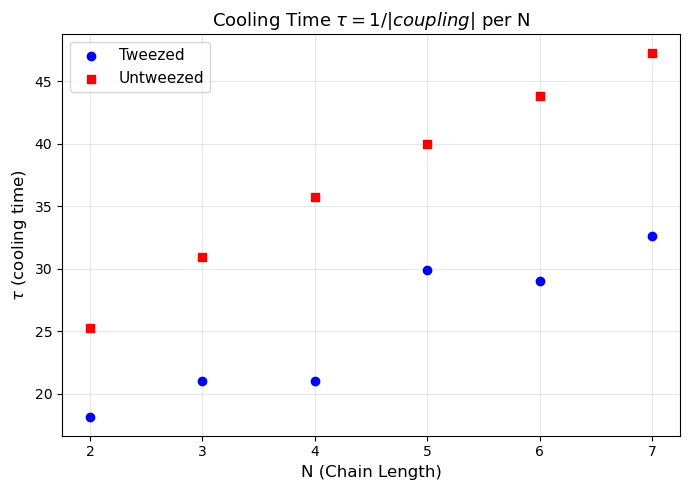

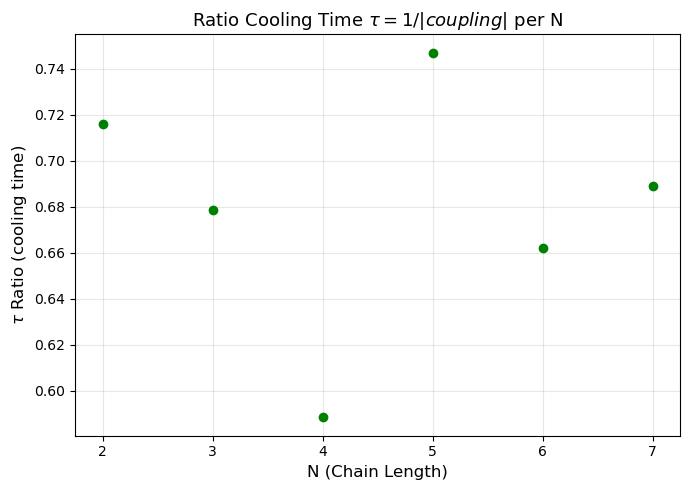

In [41]:
tweezed_data = {}  # {N: score}

for N_val, winners in results_test_check:
    if not winners:
        continue
    
    # Just take the first winner (it's already the best)
    win = winners[0]
    
    # Extract tweezed ion directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)):
        tweezed_ion = win[0][0]
    else:
        tweezed_ion = win[0]
    
    if tweezed_ion is None:
        continue  # Skip untweezed
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        tweezed_data[N_val] = abs(score)

# --- Extract untweezed winning scores (same approach) ---
untweezed_data = {}  # {N: score}

for N_val, winners in untweezed_results:
    if not winners:
        continue
    
    # Just take the first winner
    win = winners[0]
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        untweezed_data[N_val] = abs(score)

# --- Prepare arrays for plotting ---
N_tweezed = sorted(tweezed_data.keys())
scores_tweezed = [tweezed_data[N] for N in N_tweezed]

N_untweezed = sorted(untweezed_data.keys())
scores_untweezed = [untweezed_data[N] for N in N_untweezed]

# Convert to 1/score (tau) for better visibility
tau_tweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_tweezed])
tau_untweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_untweezed])

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed, marker='o', color='blue', 
            label='Tweezed', zorder=3)
ax.scatter(N_untweezed, tau_untweezed, marker='s', color='red', 
            label='Untweezed', zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ (cooling time)', fontsize=12)
ax.set_title(r'Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed/tau_untweezed, marker='o', color='green', 
            zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ Ratio (cooling time)', fontsize=12)
ax.set_title(r'Ratio Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Power Sweep


In [42]:
N_values = np.arange(2,8)
w0 = 1e-6
P_list = np.linspace(1e-6,5,50)  # optical powers from 10 mW to 1 W
# --- Run power sweep using your tweezed-only function ---
power_results = [ [] for _ in N_values]  # List of lists to hold winners for each N
for N in N_values:
    for P in P_list:
        winners = run_optimal_mode_selection_tweezed_only(
            omega_tweezer,
            linewidths,
            omega_res,
            m,
            mode_calc_r,
            N,
            f_rf_r,
            ueq_equally_spaced,
            P,
            w0,
            max_tweezed=1
        )
        power_results[N-2].append(winners)


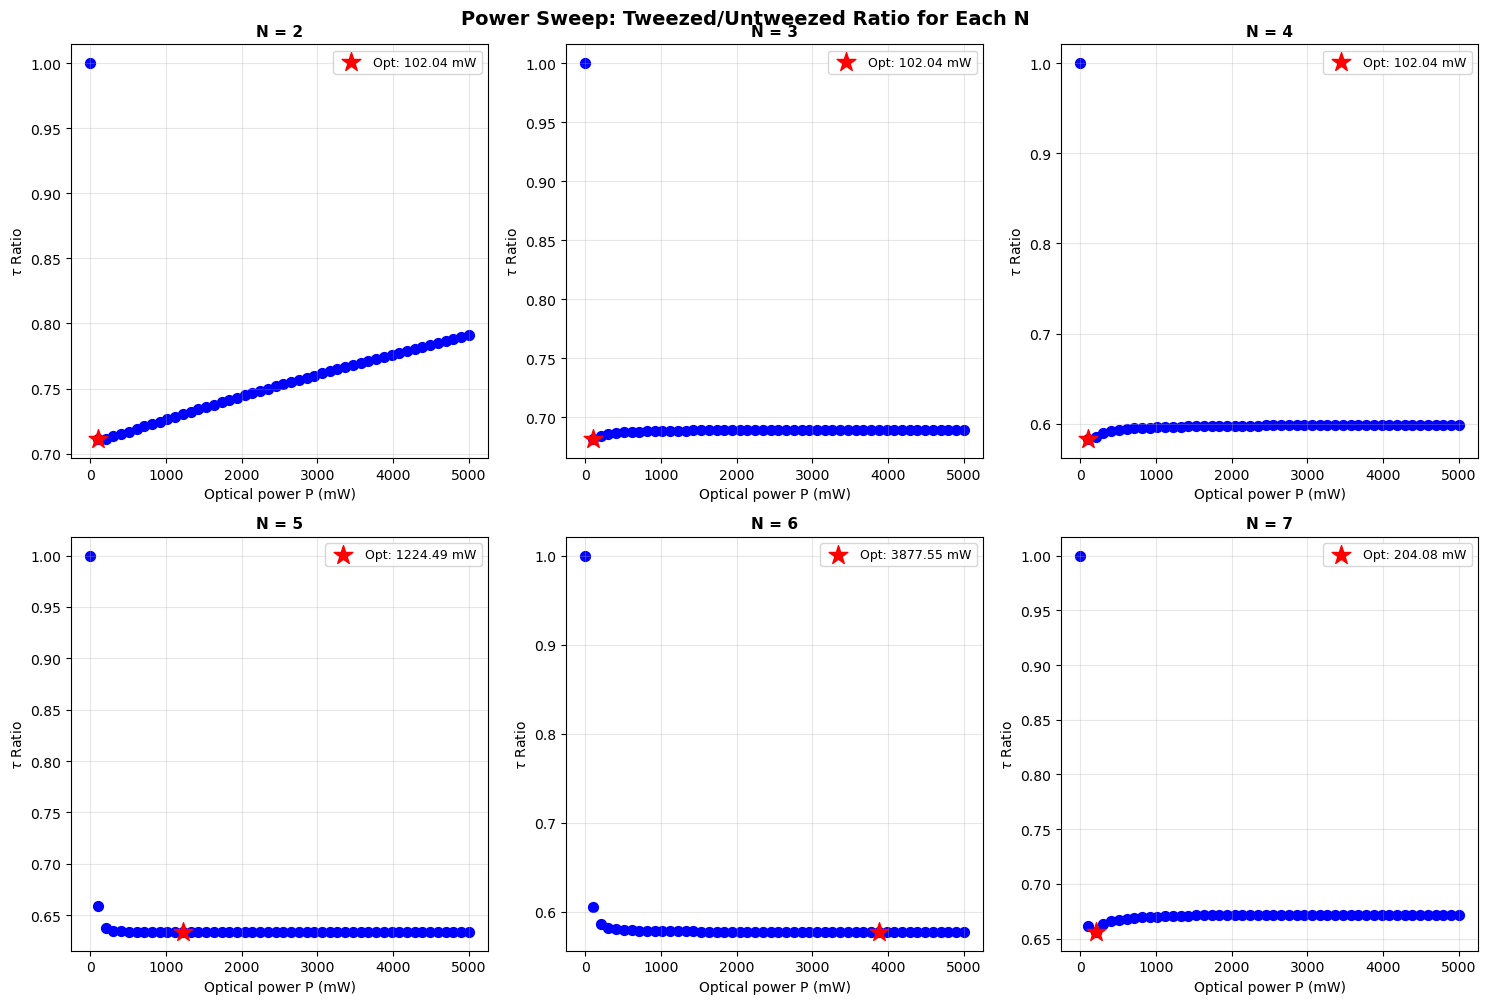


Optimal Powers Summary:
N = 2: P_opt = 1.020418e-01 W = 102.0418 mW,  Ratio = 0.7110
N = 3: P_opt = 1.020418e-01 W = 102.0418 mW,  Ratio = 0.6813
N = 4: P_opt = 1.020418e-01 W = 102.0418 mW,  Ratio = 0.5826
N = 5: P_opt = 1.224491e+00 W = 1224.4906 mW,  Ratio = 0.6337
N = 6: P_opt = 3.877551e+00 W = 3877.5512 mW,  Ratio = 0.5775
N = 7: P_opt = 2.040826e-01 W = 204.0826 mW,  Ratio = 0.6561


In [43]:
# --- Extract and plot for each N ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

optimal_powers_W = []
optimal_powers_mW = []
optimal_ratios = []

for Ni in range(2,8):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq_equally_spaced,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))
untweezed_winners = [abs(winners[0][2]) for Ni, winners in untweezed_results]

for idx, N in enumerate(N_values):
    x_tweezed = []
    y_tweezed = []
    
    # Extract scores from power_results for this N
    for P_opt, winners in zip(P_list, power_results[N-2]):
        if not winners:
            continue
        winner = winners[0]
        
        if len(winner) >= 3:
            tweezed_ion = winner[0]
            score = winner[2]
        else:
            continue
        
        if tweezed_ion is None:
            continue
        
        x_tweezed.append(P_opt)
        y_tweezed.append(abs(score))
    
    x_tweezed = np.array(x_tweezed)
    y_tweezed = np.array(y_tweezed)
    
    untweezed_ref = untweezed_winners[N-2]
    
    if len(y_tweezed) > 0:
        ratio = untweezed_ref / y_tweezed
        opt_idx = np.argmin(ratio)
        
        opt_power_W = x_tweezed[opt_idx]
        opt_power_mW = opt_power_W * 1e3
        opt_ratio = ratio[opt_idx]
        
        optimal_powers_W.append(opt_power_W)
        optimal_powers_mW.append(opt_power_mW)
        optimal_ratios.append(opt_ratio)
        
        # Plot
        axes[idx].scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50)
        axes[idx].set_xlabel("Optical power P (mW)", fontsize=10)
        axes[idx].set_ylabel(r"$\tau$ Ratio", fontsize=10)
        axes[idx].set_title(f"N = {N}", fontsize=11, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        
        axes[idx].scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*', 
                         zorder=5, label=f'Opt: {opt_power_mW:.2f} mW')
        axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Power Sweep: Tweezed/Untweezed Ratio for Each N", 
             fontsize=14, fontweight='bold', y=1.00)
plt.show()

# --- Print summary (AFTER loop completes) ---
optimal_powers_W = np.array(optimal_powers_W)
optimal_powers_mW = np.array(optimal_powers_mW)
optimal_ratios = np.array(optimal_ratios)

print("\nOptimal Powers Summary:")
print("=" * 60)
for N, P_W, P_mW, ratio in zip(N_values, optimal_powers_W, optimal_powers_mW, optimal_ratios):
    print(f"N = {N}: P_opt = {P_W:.6e} W = {P_mW:.4f} mW,  Ratio = {ratio:.4f}")
print("=" * 60)

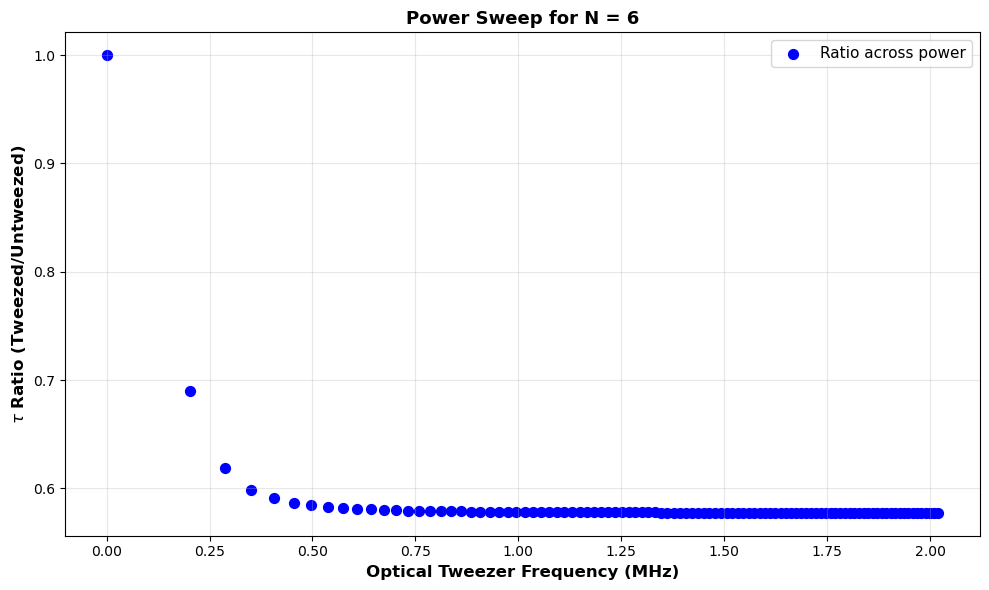


Optimal Power for N = 6:
P_opt = 3.878788e+00 W = 3878.7879 mW
Ratio = 0.5775


In [44]:
# Plot power sweep for N=6 alone

N = 6
w0 = 1e-6
P_list = np.linspace(1e-6, 4, 100)  # optical powers

# Run power sweep for N=6
power_results_N6 = []
tweezer_freqs_results_N6 = []
for P in P_list:
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq_equally_spaced,
        P,
        w0,
        max_tweezed=1
    )
    #x axis as tweezer frequency instead:
    tweezer_freqs = omega_tweezer_r(potential(omega_tweezer,linewidths,omega_res,P,w0),w0,m)
    tweezer_freqs_results_N6.append(tweezer_freqs)

    power_results_N6.append(winners)

# Get untweezed reference for N=6
untweezed_winners_N6 = untweezed_winners[N-2]

# Extract data
x_tweezed = []
y_tweezed = []

for P_val, winners in zip(P_list, power_results_N6):
    if not winners:
        continue
    winner = winners[0]
    
    if len(winner) >= 3:
        tweezed_ion = winner[0]
        score = winner[2]
    else:
        continue
    
    if tweezed_ion is None:
        continue
    
    x_tweezed.append(P_val)
    y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# Calculate ratio
ratio = untweezed_winners_N6 / y_tweezed
opt_idx = np.argmin(ratio)

opt_power_W = x_tweezed[opt_idx]
opt_power_mW = opt_power_W * 1e3
opt_ratio = ratio[opt_idx]



# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(np.array(tweezer_freqs_results_N6)/(2.0*pi*1e6), ratio, marker='o', color='blue', s=50, label='Ratio across power')
#ax.scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*', 
           #zorder=5, label=f'Optimal: P={opt_power_mW:.2f} mW, Ratio={opt_ratio:.4f}')
ax.set_xlabel("Optical Tweezer Frequency (MHz)", fontsize=12, fontweight='bold')
ax.set_ylabel(r"$\tau$ Ratio (Tweezed/Untweezed)", fontsize=12, fontweight='bold')
ax.set_title(f"Power Sweep for N = {N}", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nOptimal Power for N = {N}:")
print("=" * 60)
print(f"P_opt = {opt_power_W:.6e} W = {opt_power_mW:.4f} mW")
print(f"Ratio = {opt_ratio:.4f}")
print("=" * 60)

In [45]:
# Show winner for N=6 at the optimal power found earlier
N = 6
P_opt_N6 = float(optimal_powers_W[N-2])

winners_N6 = run_optimal_mode_selection_untweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    ueq_equally_spaced,
    P_opt_N6,
    w0
)

if winners_N6:
    best = winners_N6[0]
    print("N =", N, "P_opt (W) =", P_opt_N6)
    print("Winner (best):", best)
else:
    print("No winner returned for N =", N, "at P =", P_opt_N6)

N = 6 P_opt (W) = 3.877551244897959
Winner (best): (nan, (5, 0, 2, 1, 4, 3), -0.022845350171271244, 3.877551244897959, array([-0.02284535, -0.03183427,  0.0271274 ,  0.02476363, -0.03233192,
       -0.03254412]))


/var/folders/hl/x665hsbj3yb97s38tndz24lw0000gn/T/ipykernel_74078/3645920863.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


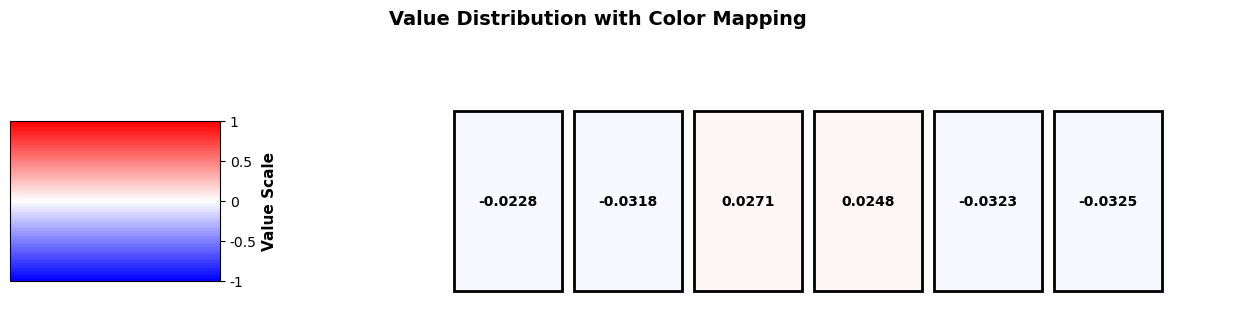

In [46]:
# Create colorbar and 6 colored rectangles with values inside
vals = np.array([-0.02284535, -0.03183427,  0.0271274 ,  0.02476363, -0.03233192,
       -0.03254412])

# Create a diverging colormap: red (-1) -> white (0) -> blue (1)
colors_div = ['red', 'white', 'blue']
n_bins = 100
cmap_div = mcolors.LinearSegmentedColormap.from_list('red_white_blue', colors_div, N=n_bins)
cmap_div_r = cmap_div.reversed()

# Define normalization from -1 to 1
norm = mcolors.Normalize(vmin=-1, vmax=1)

fig = plt.figure(figsize=(14, 4))

# --- Create colorbar on the left ---
cax_colorbar = fig.add_axes([0.08, 0.3, 0.15, 0.4])
cb = mcolorbar.ColorbarBase(
    cax_colorbar,
    cmap=cmap_div_r,
    norm=norm,
    orientation='vertical',
)
cb.set_label("Value Scale", fontsize=11, fontweight='bold')
cb.set_ticks([-1, -0.5, 0, 0.5, 1])
cb.set_ticklabels(['-1', '-0.5', '0', '0.5', '1'])

# --- Create 6 rectangles with values ---
ax_rects = fig.add_axes([0.35, 0.2, 0.6, 0.6])
ax_rects.set_xlim(-0.5, 6.5)
ax_rects.set_ylim(0, 2)
ax_rects.axis('off')

# Draw rectangles
rect_width = 0.9
rect_height = 1.5
y_pos = 0.25

for i, val in enumerate(vals):
    x_pos = i + 0.05
    
    # Get color from the colormap
    color = cmap_div_r(norm(val))
    
    # Draw rectangle
    rect = plt.Rectangle((x_pos, y_pos), rect_width, rect_height, 
                         facecolor=color, edgecolor='black', linewidth=2)
    ax_rects.add_patch(rect)
    
    # Determine text color for contrast
    text_color = 'white' if abs(val) > 0.3 else 'black'
    
    # Add text in the center of rectangle
    ax_rects.text(x_pos + rect_width/2, y_pos + rect_height/2, 
                 f'{val:.4f}', 
                 ha='center', va='center', 
                 fontsize=10, fontweight='bold', color=text_color)

plt.suptitle('Value Distribution with Color Mapping', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [47]:
P_opt = optimal_powers_W 
w0 = 1e-6
f_rf_r = 3e6
f_rf_a= 0.125e6

results_test_check = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq_equally_spaced,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_test_check.append((Ni, winners))

untweezed_results = []

for Ni in range(2,8):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq_equally_spaced,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))

untweezed_winners = [untweezed_results[i-2][1][0][2] for i in range(2,8)]

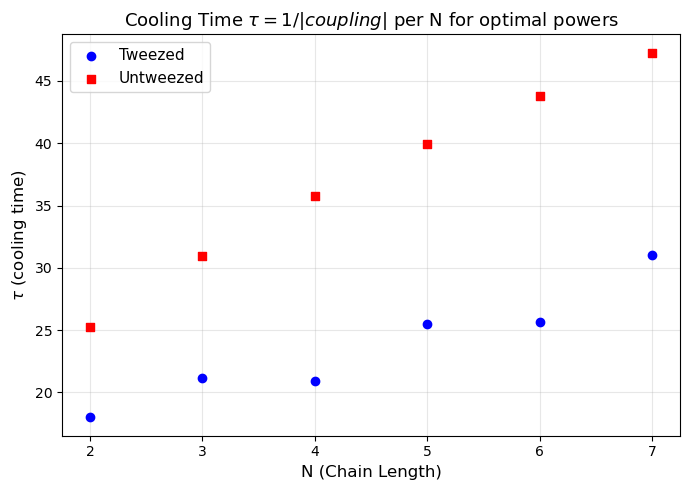

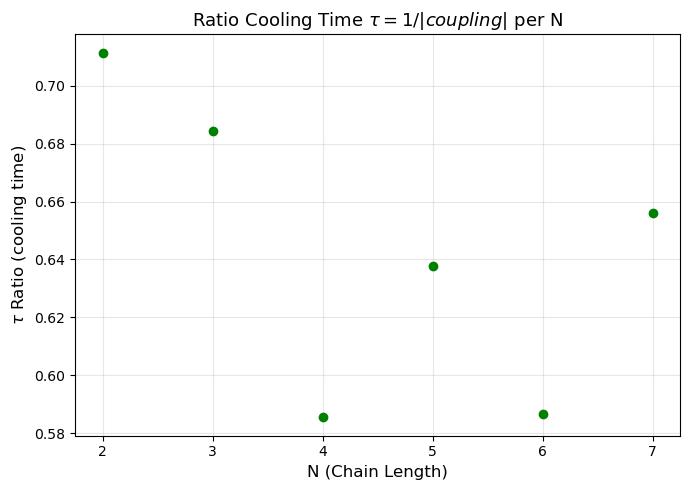

In [48]:
tweezed_data = {}  # {N: score}

for N_val, winners in results_test_check:
    if not winners:
        continue
    
    # Just take the first winner (it's already the best)
    win = winners[0]
    
    # Extract tweezed ion directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)):
        tweezed_ion = win[0][0]
    else:
        tweezed_ion = win[0]
    
    if tweezed_ion is None:
        continue  # Skip untweezed
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        tweezed_data[N_val] = abs(score)

# --- Extract untweezed winning scores (same approach) ---
untweezed_data = {}  # {N: score}

for N_val, winners in untweezed_results:
    if not winners:
        continue
    
    # Just take the first winner
    win = winners[0]
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        untweezed_data[N_val] = abs(score)

# --- Prepare arrays for plotting ---
N_tweezed = sorted(tweezed_data.keys())
scores_tweezed = [tweezed_data[N] for N in N_tweezed]

N_untweezed = sorted(untweezed_data.keys())
scores_untweezed = [untweezed_data[N] for N in N_untweezed]

# Convert to 1/score (tau) for better visibility
tau_tweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_tweezed])
tau_untweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_untweezed])

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed, marker='o', color='blue', 
            label='Tweezed', zorder=3)
ax.scatter(N_untweezed, tau_untweezed, marker='s', color='red', 
            label='Untweezed', zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ (cooling time)', fontsize=12)
ax.set_title(r'Cooling Time $\tau = 1/|coupling|$ per N for optimal powers', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed/tau_untweezed, marker='o', color='green', 
            zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ Ratio (cooling time)', fontsize=12)
ax.set_title(r'Ratio Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#midcircuit

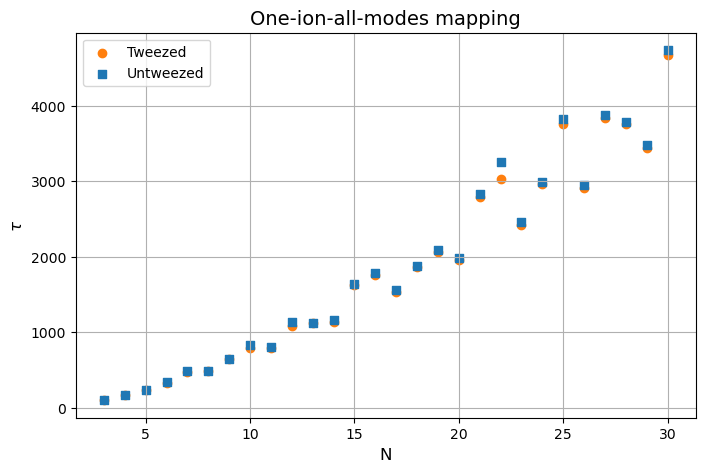

In [49]:
N = np.arange(3,4)
P = [1e-3]
w0 = 1e-6
f_rf_r = 3e6
f_rf_a = 0.125e6

dfs = []
many_N = []

ueq_equally_spaced_31 = {N:equally_spaced_positions(N, ion_spacing(N,w_rf_a)[0][1]-ion_spacing(N,w_rf_a)[0][0]) for N in range(3, 31)}  

for N in range(3, 31):
    test_loop = midcircuit_modes(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq_equally_spaced_31,
        P,
        w0,
    )
    many_N.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs.append(df)



# ...existing code...
dfs_untweezed = []
many_N_untweezed = []

for N in range(3, 31):
    test_loop = midcircuit_modes_untweezed(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq_equally_spaced_31,
        P,
        w0,
    )
    many_N_untweezed.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs_untweezed.append(df)
# combine per-N DataFrames if not already done

combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

plt.figure(figsize=(8,5))
if Ns_t.size:
    plt.scatter(Ns_t, vals_t, marker='o', color='C1', label='Tweezed')
if Ns_u.size:
    plt.scatter(Ns_u, vals_u, marker='s', color='C0', label='Untweezed')
plt.xlabel("N",fontsize = 12)
plt.ylabel(r"$\tau$", fontsize=12)
plt.title("One-ion-all-modes mapping",fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

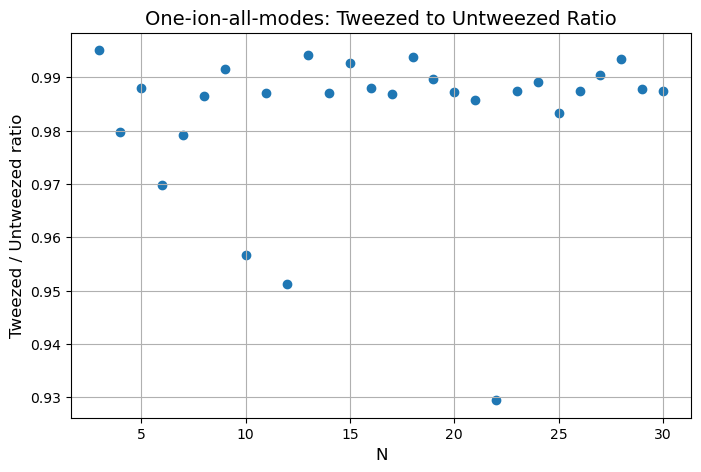

In [50]:
# Calculate ratio of tweezed to untweezed
common_N = sorted(set(Ns_t).intersection(set(Ns_u)))
ratio_vals = []

for N in common_N:
    idx_t = np.where(Ns_t == N)[0]
    idx_u = np.where(Ns_u == N)[0]
    if len(idx_t) > 0 and len(idx_u) > 0:
        val_t = vals_t[idx_t[0]]
        val_u = vals_u[idx_u[0]]
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = val_t / val_u if val_u != 0 else np.nan
        ratio_vals.append(ratio)
    else:
        ratio_vals.append(np.nan)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(common_N, ratio_vals, marker='o')
plt.xlabel("N", fontsize=12)
plt.ylabel(r"Tweezed / Untweezed ratio", fontsize=12)
plt.title("One-ion-all-modes: Tweezed to Untweezed Ratio", fontsize=14)
plt.grid(True)
#plt.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, label='Ratio = 1')
#plt.legend()
plt.show()

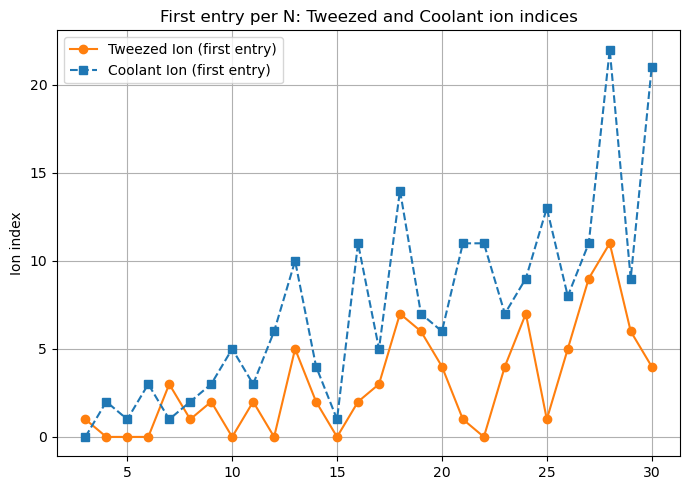

In [51]:

def _get_df_for_N(many, combined, N):
    if isinstance(many, list):
        for n, item in many:
            if n == N:
                if isinstance(item, pd.DataFrame):
                    return item.copy().reset_index(drop=True)
                return None
    if isinstance(combined, pd.DataFrame) and not combined.empty:
        tmp = combined[combined['N'] == N]
        if not tmp.empty:
            return tmp.copy().reset_index(drop=True)
    return None

many = globals().get('many_N')
combined = globals().get('combined_df')

if isinstance(many, list) and many:
    Ns = sorted({n for n, _ in many})
elif isinstance(combined, pd.DataFrame) and not combined.empty and 'N' in combined.columns:
    Ns = sorted(combined['N'].unique())
else:
    Ns = list(range(3, 30))

Ns = list(Ns)
first_t = []
first_c = []
second_t = []
second_c = []

for N in Ns:
    df = _get_df_for_N(many, combined, N)
    if df is None or df.empty:
        first_t.append(np.nan); first_c.append(np.nan)
        second_t.append(np.nan); second_c.append(np.nan)
        continue

    def safe_int(x):
        try:
            return int(x)
        except Exception:
            try:
                return int(float(x))
            except Exception:
                return np.nan

    # first entry (row 0)
    r0 = df.iloc[0]
    first_t.append(safe_int(r0.get('Tweezed Ion', np.nan)))
    first_c.append(safe_int(r0.get('Coolant Ion', np.nan)))

    # second entry (row 1) if available
    if len(df) > 1:
        r1 = df.iloc[1]
        second_t.append(safe_int(r1.get('Tweezed Ion', np.nan)))
        second_c.append(safe_int(r1.get('Coolant Ion', np.nan)))
    else:
        second_t.append(np.nan); second_c.append(np.nan)

# Plot
fig, axes = plt.subplots(1, 1, figsize=(7,5), sharex=True)

axes.plot(Ns, first_t, marker='o', linestyle='-', color='C1', label='Tweezed Ion (first entry)')
axes.plot(Ns, first_c, marker='s', linestyle='--', color='C0', label='Coolant Ion (first entry)')
axes.set_ylabel('Ion index')
axes.set_title('First entry per N: Tweezed and Coolant ion indices')
axes.grid(True)
axes.legend()




plt.tight_layout()
plt.show()


In [52]:
def sweep_power_and_find_minima(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    Ns_to_sweep,
    f_rf_r,
    f_rf_a,
    w0,
    power_values,
):
    """
    Sweep power values for given N values and find minimum tweezed/untweezed ratio.
    
    Parameters:
    -----------
    omega_tweezer, linewidths, omega_res, m, mode_calc_r : system parameters
    Ns_to_sweep : list of N values to evaluate
    f_rf_r, f_rf_a, w0 : RF and tweezer parameters
    power_values : array of power values (in watts) to sweep
    
    Returns:
    --------
    Dictionary with keys:
        't_vals': dict mapping N to list of tweezed metric values
        'u_vals': dict mapping N to list of untweezed metric values
        'ratio_vals': dict mapping N to list of ratio values
        'min_power_indices': dict mapping N to (min_power_mW, min_ratio)
        'power_values': the input power array for reference
    """
    
    def first_sum_by_N(df):
        if df is None or df.empty:
            return np.array([]), np.array([])
        first = df.groupby("N", sort=True, as_index=False).first()
        return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()
    
    t_vals = {N: [] for N in Ns_to_sweep}
    u_vals = {N: [] for N in Ns_to_sweep}
    ratio_vals = {N: [] for N in Ns_to_sweep}
    
    for p in power_values:
        P_current = [p]
        for N_fixed in Ns_to_sweep:
            # tweezed
            test_loop = midcircuit_modes(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, f_rf_a, P_current, w0
            )
            dfs = []
            if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
                df = test_loop.copy().reset_index(drop=True)
                df['N'] = int(N_fixed)
                dfs = [df]
            
            # untweezed
            test_loop_u = midcircuit_modes_untweezed(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, f_rf_a, P_current, w0
            )
            dfs_untweezed = []
            if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
                dfu = test_loop_u.copy().reset_index(drop=True)
                dfu['N'] = int(N_fixed)
                dfs_untweezed = [dfu]
            
            combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
            combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()
            
            _, vals_t_arr = first_sum_by_N(combined_df)
            _, vals_u_arr = first_sum_by_N(combined_untweezed)
            
            val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
            val_u = vals_u_arr[0] if vals_u_arr.size else np.nan
            
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.nan if (np.isnan(val_t) or np.isnan(val_u) or val_u == 0) else (val_t / val_u)
            
            t_vals[N_fixed].append(val_t)
            u_vals[N_fixed].append(val_u)
            ratio_vals[N_fixed].append(ratio)
    
    # Find minimum ratio for each N
    min_power_indices = {}
    for N_fixed in Ns_to_sweep:
        ratio_list = ratio_vals[N_fixed]
        min_ratio = np.nanmin(ratio_list)
        min_idx = np.nanargmin(ratio_list)
        min_power_mW = power_values[min_idx] * 1e3
        min_power_indices[N_fixed] = (min_power_mW, min_ratio)
    
    return {
        't_vals': t_vals,
        'u_vals': u_vals,
        'ratio_vals': ratio_vals,
        'min_power_indices': min_power_indices,
        'power_values': power_values,
    }

[2.00644051 2.45087514 3.08438777 3.58820925 4.07503548 4.54807792
 5.00965137] MHz


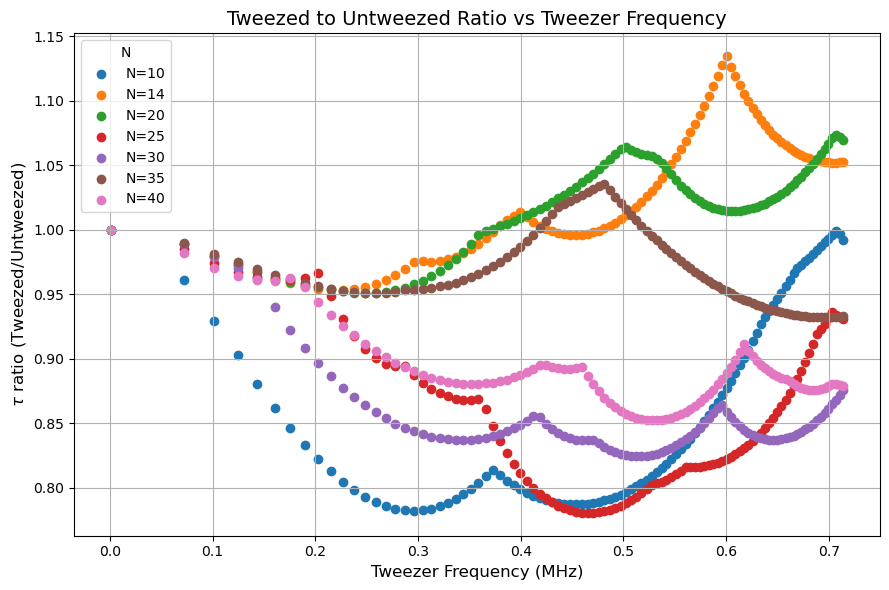

In [53]:
# Sweep power and plot tweezed/untweezed ratio vs tweezer frequency
w0 = 1e-6
f_rf_a = 300e3
Ns_to_plot = [10,14,20,25,30,35,40]

# Build ueq_equally_spaced for all N values
w_rf_a = f_rf_a * 2 * np.pi
ueq_equally_spaced = {N: equally_spaced_positions(N, ion_spacing(N, w_rf_a)[0][1] - ion_spacing(N, w_rf_a)[0][0]) for N in Ns_to_plot}

# precompute f_rf_r for each N
f_rf_r_by_N = {Nval: (0.77 * Nval * f_rf_a * 2) / np.log(Nval) for Nval in Ns_to_plot}
print(np.array(list(f_rf_r_by_N.values())) / 1e6, "MHz")

power_values = np.linspace(1e-6, 500e-3, 100)

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}
tweezer_freqs = {N: [] for N in Ns_to_plot}  # Store tweezer frequencies

for p in power_values:
    P_current = [p]

    # Calculate tweezer frequency for this power (same for all N for given p)
    tweezer_freq = omega_tweezer_r(
        potential(omega_tweezer, linewidths, omega_res, p, w0),
        w0, m
    )

    for N_fixed in Ns_to_plot:
        f_rf_r_local = f_rf_r_by_N[N_fixed]

        # tweezed
        test_loop = midcircuit_modes(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r_local, ueq_equally_spaced, P_current, w0
        )
        dfs = []
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            dfs = [df]

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r_local, ueq_equally_spaced, P_current, w0
        )
        dfs_untweezed = []
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            dfs_untweezed = [dfu]

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) or np.isnan(val_u) or val_u == 0) else (val_t / val_u)

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)
        tweezer_freqs[N_fixed].append(tweezer_freq)  # Store frequency for this N

# --- Plot: ratio curves vs tweezer frequency ---
plt.figure(figsize=(9, 6))
colors = plt.cm.tab10.colors

for i, N_fixed in enumerate(Ns_to_plot):
    # Convert frequencies to MHz for readability
    freqs_MHz = np.array(tweezer_freqs[N_fixed]) / (2 * np.pi * 1e6)
    plt.scatter(freqs_MHz, ratio_vals[N_fixed], marker='o',
                color=colors[i % len(colors)], label=f'N={N_fixed}')

plt.xlabel("Tweezer Frequency (MHz)", fontsize=12)
plt.ylabel(r"$\tau$ ratio (Tweezed/Untweezed)", fontsize=12)
plt.title("Tweezed to Untweezed Ratio vs Tweezer Frequency", fontsize=14)
plt.grid(True)
plt.legend(title="N")
plt.tight_layout()
plt.show()
